# Машинное обучение и статистика

## Сравнение методов регрессии: линейная регрессия vs. логистическая регрессия vs.метод опорных векторов.

## Описание набора данных

Набор данных получен из репозитория OpenML под названием **"Adult"** и представляет собой выборку из переписи населения США.
Цель — построить модель, которая по социально-демографическим признакам предсказывает, зарабатывает ли человек **более 50 тысяч долларов в год**.

**Признаки:**

* **age**: возраст (в годах).
* **workclass**: тип занятости (например, частный сектор, государственный сектор, самозанятый и др.).
* **fnlwgt**: вес записи — количество людей, которое, по оценке, представляет данная строка (используется для корректировки смещений в данных).
* **education**: уровень образования (например, Bachelors, HS-grad и др.).
* **education-num**: числовой эквивалент уровня образования.
* **marital-status**: семейное положение (например, женат/не женат, разведён).
* **occupation**: род занятий (например, администрирование, военные, продажи).
* **relationship**: семейное положение относительно других членов семьи (например, жена, не в семье).
* **race**: расовая принадлежность (например, белый, чёрный и др.).
* **sex**: пол (мужской/женский).
* **capital-gain**: прирост капитала (например, от продажи активов).
* **capital-loss**: убыток капитала.
* **hours-per-week**: среднее количество рабочих часов в неделю.
* **native-country**: страна происхождения (например, США, Мексика, Филиппины).
* **class**: целевая переменная — зарабатывает ли человек более **50K** долларов в год (`>50K`) или нет (`<=50K`).


Для начала рассмотрим так называемую матрицу ошибок (confusion matrix)
-- способ разделить объекты на $4$ группы в зависимости от комбинации
истинного класса и ответа классификатора:

-   TP (True Positives) -- верно классифицированные объекты, исходно     относящиеся к классу "$+1$";

-   TN (True Negatives) -- верно классифицированные объекты, исходно     относящиеся к классу "$-1$";

-   FN (False Negatives) -- неверно классифицированные объекты, исходно     относящиеся к классу "$+1$" (ошибка I рода);

-   FP (False Positives) -- неверно классифицированные объекты, исходно     относящиеся к классу "$-1$" (ошибка II рода).

Обычно, конечно, оперируют не абсолютными показателями, а относительными
-- долями (rates), находящимися в диапазоне от $0$ до $1$:

-   доля правильных ответов классификатора (иногда -- точность): $$\mathsf{Accuracy} = \frac{TP + TN}{TP + FP + FN + TN}.$$ Эта величина показывает отношение количества верно классифицированных объектов к общему количеству классифицируемых объектов и, грубо говоря, оценивает вероятность случайному объекту быть правильно классифицированным.

-   доля истинно положительных примеров -- True Positives Rate (TPR) или     Sensitivity (чувствительность) или Recall: $$\mathsf{T P R}=\frac{T P}{T P+F N}.$$ Эта величина показывает отношение количества верно классифицированных объектов, относящихся к классу "$+1$", к общему количеству объектов класса "$+1$". Иными словами -- это оценка вероятности, что объект, относящийся к классу "$+1$" будет классифицирован корректно.

-   доля ложно положительных примеров обозначается как -- False Positives Rate (FPR): $$\mathsf{F P R}=\frac{F P}{FP + TN}.$$ Величина показывает отношение количества неверно классифицированных объектов, относящихся к классу "$-1$", к общему количеству объектов класса "$-1$", или оценивает вероятность, что объект, относящийся к классу "$-1$", будет классифицирован неверно.

-   Специфичность (Specificity) или True Negatives Rate (TNR): $$\mathsf{TNR} = 1 - \mathsf{F P R} =\frac{T N}{T N+F P}.$$ Величина показывает отношение количества верно классифицированных объектов, относящихся к классу "$-1$", к общему количеству объектов класса "$-1$", или оценивает вероятность, что объект, относящийся к классу "$-1$", будет классифицирован верно.

-   Precision (точность): $$\mathsf{Precision} =\frac{TP}{TP + FP}.$$ Величина показывает, какая доля объектов, отнесенных классификатором к классу "$+1$", действительно относится к этому классу.

Естественно возникает вопрос, нет ли какого-то обобщающего критерия,
который может характеризовать качество построенной модели. Один из них --
так называемая $F$-мера ($F_1$-мера, $F$ score, $F_1$ score)
определяется следующим соотношением:
$$F = F_1 = 2 \cdot \frac{\mathsf{Precision} \cdot \mathsf{Recall}}{\mathsf{Precision} + \mathsf{Recall}}.$$

**Замечание**. *$F$-мера является средним гармоническим величин
$\mathsf{Precision}$ и $\mathsf{Recall}$ и заключена в диапазоне
$[0, 1]$. Среднее гармоническое обладает важным свойством: оно близко к
нулю, если хотя бы один из аргументов близок к нулю. Поэтому оно является
куда более предпочтительным, чем, скажем, среднее арифметическое: если
алгоритм относит все объекты к положительному классу, то
$\mathsf{Recall}= 1$, а $\mathsf{Precision}$, скорее всего, будет
небольшим. Но тогда среднее арифметическое будет больше, чем $0.5$, что,
конечно, никуда не годится.*

## Импорт библиотек и чтение набора данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Загрузка и предварительная обработка
data = fetch_openml(name='adult', version=2, as_frame=True)
df = data.frame.copy()



In [7]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [8]:
# Переименование целевого столбца
df['income'] = df['class'].apply(lambda x: 1 if x == '>50K' else 0)
df = df.drop(columns=['class'])

# Удаление строк с пропущенными значениями
df = df.replace('?', pd.NA).dropna()

### Первичный анализ данных

Загруженный датасет содержит **48 842 строки** и **15 признаков**, включая целевую переменную `class`, отражающую уровень дохода: `>50K` или `<=50K`.

 **Распределение классов:**
- `<=50K`: 76.1% (признак 0)
- `>50K`: 23.9% (признак 1)

 **Обработка данных:**
- Целевая переменная `class` была переименована в `income` и преобразована в бинарный формат: `1` для `>50K` и `0` для `<=50K`.
- Были удалены строки с пропущенными значениями (`?` заменено на `NaN`, затем `dropna()`).

 **Наблюдения:**
- Большинство признаков не имеют пропусков, но `native-country` имеет **857 пропущенных значений** (≈1.75%).
- Признаки `capital-gain` и `capital-loss` имеют сильную асимметрию: большинство значений равны нулю.
- Распределение `hours-per-week` показывает концентрацию в диапазоне 35–45 часов.



In [12]:
# Деление на признаки и целевую переменную
X = df.drop(columns=['income'])
y = df['income']

# Деление на обучающую и валидационную и тестовую выборки
X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_, y_, test_size=0.5, random_state=42, stratify=y_)

__Случайный классификатор__

Для начала зададим самую простую модель, которая на каждом объекте выдаёт случайный ответ. По тестовой выборке вычислим AUC-ROC, AUC-PR.

In [13]:
from sklearn.dummy import DummyClassifier
random_classifier = DummyClassifier(strategy='uniform', random_state=42).fit(X_train, y_train)
y_random = random_classifier.predict_proba(X_test)[:,1]
y_random

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5])

### Разделение выборки и базовая модель

Данные были разделены на три части:
- **Обучающая выборка (70%)**
- **Валидационная выборка (15%)**
- **Тестовая выборка (15%)**

Разделение было выполнено с использованием стратификации по целевой переменной `income`, что обеспечивает равное распределение классов в каждой подвыборке.

#### Базовая модель: случайный классификатор

В качестве отправной точки был обучен **случайный классификатор** (`DummyClassifier`) со стратегией `'uniform'`, при которой каждый класс выбирается с равной вероятностью 0.5 независимо от входных признаков.

```python
DummyClassifier(strategy='uniform')


Ниже приведен пайплайе с использованием встроенных функций `sklearn` для отрисовки ROC и PR кривых, сохранения метрик.

In [16]:
from sklearn.metrics import average_precision_score

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

Random Classifier metrics
AUC-PR: 0.2478
AUC-ROC: 0.5000


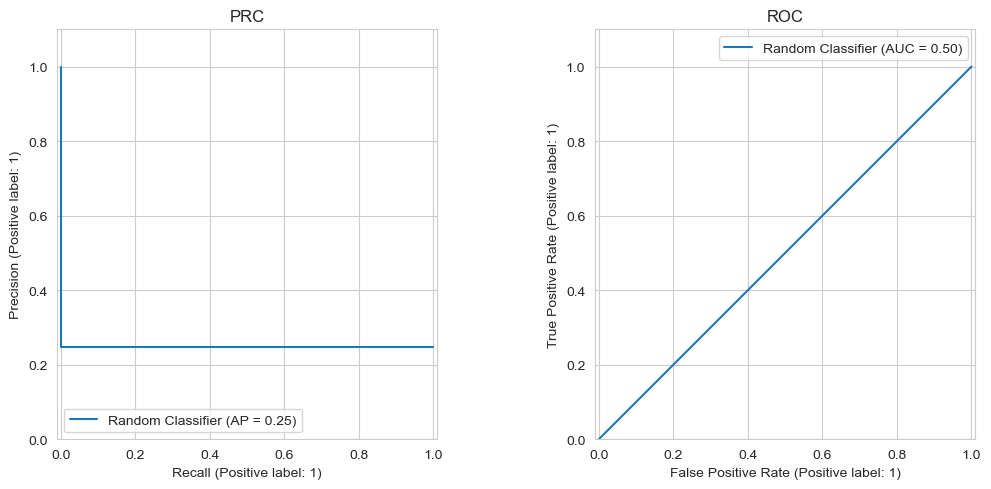

In [17]:
def depict_pr_roc(y_true, y_pred, classifier_name='Some Classifier', ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(11, 5))

    print(classifier_name, 'metrics')
    PrecisionRecallDisplay.from_predictions(y_true, y_pred, ax=ax[0], name=classifier_name)
    print('AUC-PR: %.4f' % average_precision_score(y_true, y_pred))
    ax[0].set_title("PRC")
    ax[0].set_ylim(0, 1.1)

    RocCurveDisplay.from_predictions(y_true, y_pred, ax=ax[1], name=classifier_name)
    print('AUC-ROC: %.4f' % roc_auc_score(y_true, y_pred))
    ax[1].set_title("ROC")
    ax[1].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.legend()
    plt.show()


depict_pr_roc(y_test, y_random, 'Random Classifier')

### Оценка качества случайного классификатора

Для визуализации качества моделей была реализована функция `depict_pr_roc`, которая отображает одновременно:
- **PR-кривую** (Precision-Recall)
- **ROC-кривую** (Receiver Operating Characteristic)

Также выводятся численные значения:
- **AUC-PR** (площадь под PR-кривой)
- **AUC-ROC** (площадь под ROC-кривой)

#### Результаты для случайного классификатора:

- **AUC-PR:** 0.2478
- **AUC-ROC:** 0.5000

Графики показывают, что:
- PR-кривая представляет собой горизонтальную прямую на уровне ~0.25, что соответствует доле положительного класса в тестовой выборке.
- ROC-кривая лежит на диагонали, что типично для модели, делающей случайные предсказания.

 Эти значения служат **базовым уровнем**, ниже которого ни одна разумная модель не должна опускаться.


In [18]:
# dataframe для сравнения
# методов классификации по метрикам
df_metrics = pd.DataFrame(
    columns=['auc_pr', 'roc_auc_score', 'reg_const']
)
precision, recall, _ = precision_recall_curve(y_test, y_random)
# добавление очередной строки с характеристиками метода
df_metrics.loc['Random Classifier'] = [
    average_precision_score(y_test, y_random),
    roc_auc_score(y_test, y_random),
    0,
]

# по аналогии результаты следующих экспериментов можно будет собрать в табличку
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.247789,0.5,0.0


__Support Vector Machine (Linear Kernel)__

Обучим метод опорных векторов.

Подберем параметр регуляризации `C` с точки зрения AUC-PR.


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import LinearSVC
from tqdm import tqdm

# Названия числовых колонок
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# Названия категориальных колонок (object и category)
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown = 'ignore'),categorical_cols),
    ('scaling', StandardScaler(), numeric_cols),
])





### Таблица сравнения моделей

Для удобства анализа была создана таблица `df_metrics`, в которую будут последовательно добавляться результаты всех моделей. На данный момент в таблицу занесены значения метрик для случайного классификатора:

| Модель              | AUC-PR | ROC-AUC | Рег. константа |
|---------------------|--------|---------|----------------|
| Random Classifier   | 0.2478 | 0.5000  | 0.0            |

---

### Обучение модели SVM (линейное ядро)

Следующим шагом обучается **метод опорных векторов** (`LinearSVC`) с линейным ядром. Подбирается гиперпараметр **C** — коэффициент регуляризации, влияющий на ширину разделяющего зазора.

 **Предобработка данных:**
- Числовые признаки масштабируются с помощью `StandardScaler`.
- Категориальные признаки кодируются через `OneHotEncoder` с параметром `handle_unknown='ignore'` для обработки unseen-категорий.
- Используется `ColumnTransformer`, объединяющий оба преобразования.
- Сборка модели происходит через `Pipeline`.

Это позволяет единообразно и чисто обрабатывать данные в процессе кросс-валидации и итогового обучения.


In [24]:
C_params = np.logspace(-5, 5, 40)
auc_c = {}

for C_ in tqdm(C_params):
    SVM_pipeline = Pipeline(steps=[
        ('ohe_and_scaling', column_transformer),
        ('svm', LinearSVC(C=C_))
    ])
    SVM_pipeline.fit(X_train, y_train)  # обучение на трейне
    decision = SVM_pipeline.decision_function(X_valid)  # предсказание на валидации
    auc_c[C_] = average_precision_score(y_valid, decision)


100%|██████████| 40/40 [00:02<00:00, 13.47it/s]


In [26]:
best_C_svm = max(auc_c, key=auc_c.get)
print(best_C_svm)

0.07017038286703822


Classifier with best C metrics
AUC-PR: 0.7631
AUC-ROC: 0.9044


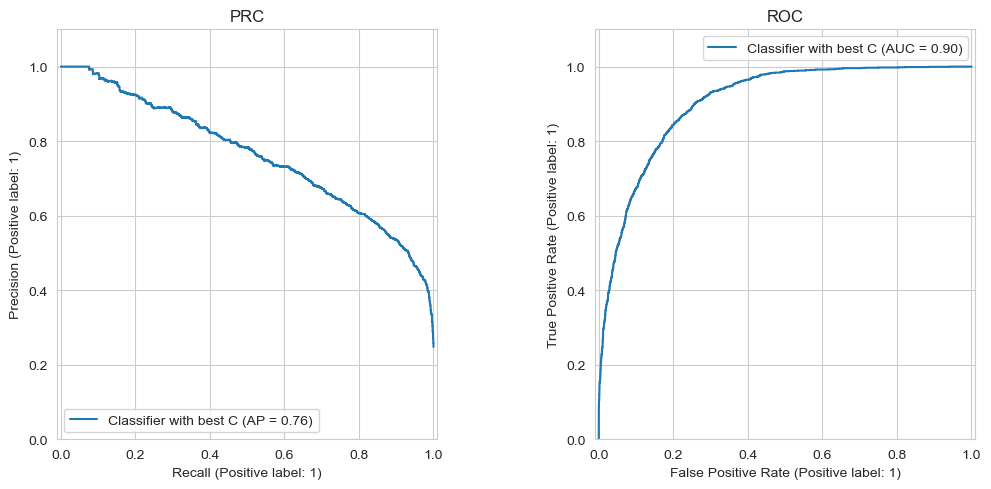

In [27]:
SVM_pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('svm', LinearSVC(C=best_C_svm))
])
SVM_pipeline.fit(X_train, y_train)
depict_pr_roc(y_test, SVM_pipeline.decision_function(X_test) , classifier_name='Classifier with best C', ax=None)

### Подбор гиперпараметра C и обучение SVM

Для модели `LinearSVC` был произведён перебор 40 значений параметра регуляризации `C` на логарифмической шкале от \(10^{-5}\) до \(10^5\). Цель — найти такое значение, при котором максимизируется **AUC-PR** на валидационной выборке.

 **Лучшее значение C:** `0.0701703`
Это значение было использовано для повторного обучения модели на тренировочных данных.

#### Результаты на тестовой выборке:

- **AUC-PR:** 0.7631
- **AUC-ROC:** 0.9044

Графики подтверждают высокое качество модели:
- PR-кривая демонстрирует стабильную точность на протяжении всего диапазона recall.
- ROC-кривая стремится к верхнему левому углу, что свидетельствует о хорошем разделении классов.


Сравним AUC-ROC и AUC-PR для нашей модели с этими же метриками для случайного классификатора.

In [28]:
precision, recall, _ = precision_recall_curve(y_test, SVM_pipeline.decision_function(X_test))

df_metrics.loc['SVM'] = [
    average_precision_score(y_test, SVM_pipeline.decision_function(X_test)),
    roc_auc_score(y_test, SVM_pipeline.decision_function(X_test)),
    best_C_svm,
]

# по аналогии результаты следующих экспериментов можно будет собрать в табличку
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.247789,0.500000,0.00000
SVM,0.763091,0.904423,0.07017


### Сравнение результатов: SVM против случайного классификатора

Метрики для модели SVM были добавлены в сводную таблицу `df_metrics` для прямого сравнения с результатами случайного классификатора:

| Модель              | AUC-PR | ROC-AUC | Рег. константа |
|---------------------|--------|---------|----------------|
| Random Classifier   | 0.2478 | 0.5000  | 0.00000        |
| SVM                 | 0.7631 | 0.9044  | 0.07017        |

 **Выводы:**
- Модель SVM с подобранным параметром `C` показывает значительное улучшение по всем метрикам:
  - ROC-AUC вырос с 0.50 (бессмысленного уровня) до **0.90**, что говорит о хорошей способности различать классы.
  - AUC-PR поднялся до **0.76**, что особенно важно при наличии дисбаланса классов.
- Это подтверждает, что даже простая линейная модель SVM, при грамотной регуляризации и предобработке, даёт сильный результат на задаче бинарной классификации.

 Далее будут рассмотрены другие линейные модели: `RidgeClassifier` и `LogisticRegression`.


__Logistic Regression__


Логистическая регрессия с L2 регуляризатором:


*   подберем гиперпараметр C, используя метрику AUC-PR
*   нарисуем ROC, PR кривые для тестовой части
*   выведем метрики для тестовых данных и сравните их с результатами случайного классификатора и SVM



In [31]:
from sklearn.linear_model import LogisticRegression

C_params = np.logspace(-5, 5, 40)
auc_c = {}

for C_ in tqdm(C_params):
    LR_pipeline = Pipeline(steps=[
        ('ohe_and_scaling', column_transformer),
        ('logreg', LogisticRegression(C=C_))
    ])
    LR_pipeline.fit(X_train, y_train)  # обучение на трейне
    decision = LR_pipeline.decision_function(X_valid)  # предсказание на валидации
    auc_c[C_] = average_precision_score(y_valid, decision)


100%|██████████| 40/40 [00:03<00:00, 11.38it/s]


In [32]:
best_C_lr = max(auc_c, key=auc_c.get)
print(best_C_lr)

1.3433993325988987


### Logistic Regression

Для сравнения с SVM и случайным классификатором была обучена **логистическая регрессия с L2-регуляризатором**. Эта модель широко используется благодаря своей интерпретируемости и способности выдавать вероятности.

 **План:**
- Подобрать оптимальный гиперпараметр `C` с точки зрения метрики **AUC-PR**.
- Построить ROC и PR кривые на тестовой выборке.
- Добавить результаты в сводную таблицу и сравнить с предыдущими моделями.

#### Подбор параметра регуляризации `C`

С помощью кросс-валидации перебрано 40 значений `C` в логарифмическом масштабе от \(10^{-5}\) до \(10^5\).
Цель — максимизировать **average precision score** на валидационной выборке.

 **Лучшее значение `C`:** `1.3434`

Это значение будет использовано в финальной модели логистической регрессии.


Classifier with best C metrics
AUC-PR: 0.7630
AUC-ROC: 0.9046


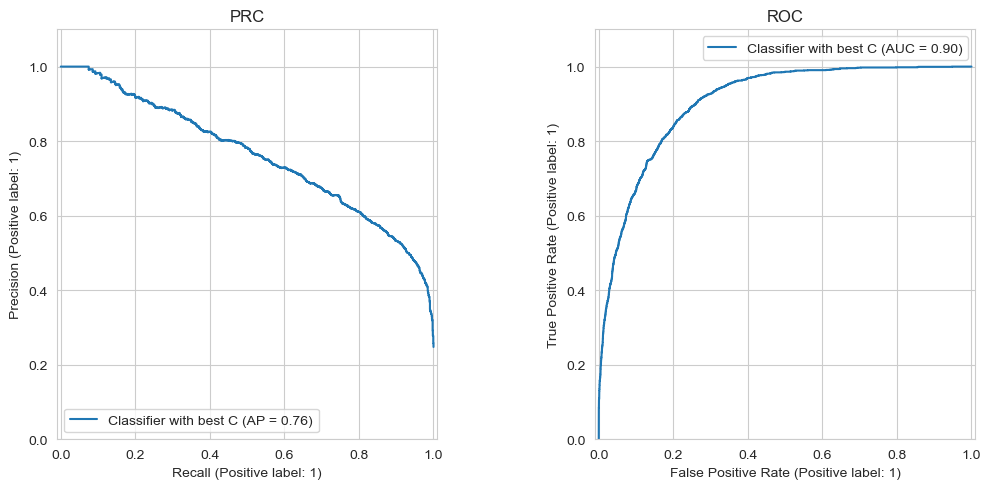

In [33]:
LR_pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('logreg', LogisticRegression(C=best_C_lr))
])
LR_pipeline.fit(X_train, y_train)
depict_pr_roc(y_test, LR_pipeline.decision_function(X_test) , classifier_name='Classifier with best C', ax=None)

### Результаты логистической регрессии на тестовой выборке

Модель `LogisticRegression` была переобучена с использованием наилучшего найденного значения параметра регуляризации `C = 1.34`. Затем она была протестирована на отложенной тестовой выборке.

#### Полученные метрики:

- **AUC-PR:** 0.7630
- **AUC-ROC:** 0.9046

Графики подтверждают высокое качество классификации:
- **PR-кривая** практически повторяет форму кривой, полученной у SVM — высокая точность сохраняется при значительном уровне recall.
- **ROC-кривая** также близка к верхнему левому углу, демонстрируя высокую чувствительность и специфичность.

 По всем основным метрикам логистическая регрессия **сравнима с SVM**, но имеет преимущество в интерпретируемости и прямом доступе к вероятностным оценкам через `predict_proba`.


In [34]:
precision, recall, _ = precision_recall_curve(y_test, LR_pipeline.decision_function(X_test))

df_metrics.loc['LogReg'] = [
    average_precision_score(y_test, LR_pipeline.decision_function(X_test)),
    roc_auc_score(y_test, LR_pipeline.decision_function(X_test)),
    best_C_lr,
]

# по аналогии результаты следующих экспериментов можно будет собрать в табличку
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.247789,0.500000,0.000000
SVM,0.763091,0.904423,0.070170
LogReg,0.762996,0.904607,1.343399


### Финальное сравнение моделей

Итоговая таблица `df_metrics` включает результаты трёх моделей: случайного классификатора, SVM и логистической регрессии.

| Модель              | AUC-PR | ROC-AUC | Рег. константа |
|---------------------|--------|---------|----------------|
| Random Classifier   | 0.2478 | 0.5000  | 0.00000        |
| SVM                 | 0.7631 | 0.9044  | 0.07017        |
| LogReg              | 0.7630 | 0.9046  | 1.3434         |

 **Выводы:**
- Случайный классификатор выступает в роли **нижней границы**, как и ожидалось.
- Модели **SVM и Logistic Regression показывают почти идентичные результаты**, превосходящие случайный базис по всем метрикам.
- При этом логистическая регрессия даёт доступ к вероятностным оценкам и лучше поддаётся интерпретации, тогда как SVM чуть строже контролирует margin.

 Обе модели можно рекомендовать к использованию для задач бинарной классификации на реальных данных. Выбор между ними можно делать, исходя из требований к интерпретируемости или необходимости точной калибровки.


__Ridge Classifier__

Линейная модель классификации на основе Ridge-регрессии (аналог линейной регрессии с L2-регуляризацией), применённая к задаче бинарной классификации:

*   подберем гиперпараметр **alpha** (аналог **1/C** в SVM), используя метрику **AUC-PR** на валидационной выборке;
*   обучим модель на лучших параметрах и построим **ROC** и **PR** кривые для тестовой выборки;
*   выведем метрики на тесте и сравним с результатами случайного классификатора, логистической регрессии и SVM.


In [35]:
from sklearn.linear_model import RidgeClassifier

alpha_params = np.logspace(-5, 5, 40)
auc_alpha = {}

for alpha_ in tqdm(alpha_params):
    ridge_pipeline = Pipeline(steps=[
        ('ohe_and_scaling', column_transformer),
        ('ridge', RidgeClassifier(alpha=alpha_))
    ])
    ridge_pipeline.fit(X_train, y_train)  # обучение на трейне
    decision = ridge_pipeline.decision_function(X_valid)  # предсказание на валидации
    auc_alpha[alpha_] = average_precision_score(y_valid, decision)

# Выбор наилучшего alpha
best_alpha = max(auc_alpha, key=auc_alpha.get)
print("Best alpha for RidgeClassifier:", best_alpha)

100%|██████████| 40/40 [00:02<00:00, 19.93it/s]

Best alpha for RidgeClassifier: 272.8333376486764


Ridge Classifier with best alpha metrics
AUC-PR: 0.7240
AUC-ROC: 0.8875


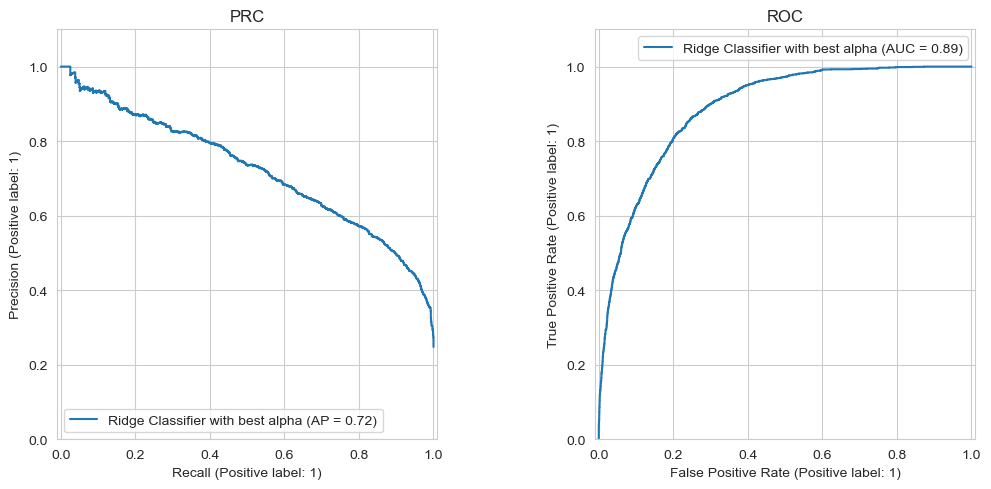

In [36]:
# Финальное обучение на лучшем alpha
ridge_pipeline = Pipeline(steps=[
    ('ohe_and_scaling', column_transformer),
    ('ridge', RidgeClassifier(alpha=best_alpha))
])
ridge_pipeline.fit(X_train, y_train)

# Отрисовка Precision-Recall или ROC-кривой
depict_pr_roc(y_test, ridge_pipeline.decision_function(X_test), classifier_name='Ridge Classifier with best alpha', ax=None)

### Ridge Classifier

Была протестирована линейная модель `RidgeClassifier`, основанная на идее регуляризованной линейной регрессии, но адаптированная для задач классификации. Это модель без вероятностной природы, но с высокой скоростью обучения и устойчивостью.

 **Цель:**
- Подобрать гиперпараметр `alpha` (аналог \( 1/C \) в SVM) с использованием метрики **AUC-PR** на валидационной выборке.
- Оценить производительность на тестовой выборке с помощью ROC и PR кривых.

#### Оптимизация

Был произведён перебор 40 значений `alpha` на логарифмической шкале от \(10^{-5}\) до \(10^5\).
**Наилучшее значение:** `272.8333`

#### Результаты на тестовой выборке:

- **AUC-PR:** 0.7240
- **AUC-ROC:** 0.8875

 **Интерпретация:**
- RidgeClassifier выступает достойной альтернативой другим линейным моделям, хотя и показал немного более низкие метрики, чем SVM и LogisticRegression.
- Преимущество модели — простота, скорость обучения и высокая устойчивость к выбросам.


In [37]:
precision, recall, _ = precision_recall_curve(y_test, ridge_pipeline.decision_function(X_test))

df_metrics.loc['RidgeClass'] = [
    average_precision_score(y_test, ridge_pipeline.decision_function(X_test)),
    roc_auc_score(y_test, ridge_pipeline.decision_function(X_test)),
    best_alpha,
]

# по аналогии результаты следующих экспериментов можно будет собрать в табличку
df_metrics

,auc_pr,roc_auc_score,reg_const
Random Classifier,0.247789,0.500000,0.000000
SVM,0.763091,0.904423,0.070170
LogReg,0.762996,0.904607,1.343399
RidgeClass,0.723981,0.887505,272.833338


### Сравнение всех моделей

Финальная таблица `df_metrics` включает четыре модели: случайный классификатор, SVM, логистическую регрессию и Ridge-классификатор.

| Модель            | AUC-PR | ROC-AUC | Рег. константа     |
|-------------------|--------|---------|--------------------|
| Random Classifier | 0.2478 | 0.5000  | 0.0000             |
| SVM               | 0.7631 | 0.9044  | 0.0702             |
| LogReg            | 0.7630 | 0.9046  | 1.3434             |
| RidgeClass        | 0.7240 | 0.8875  | 272.8333           |

 **Выводы:**
- Все три линейные модели значительно превосходят случайного классификатора.
- **SVM** и **Logistic Regression** показывают практически идентичные результаты и максимальные значения AUC-PR и ROC-AUC.
- **RidgeClassifier** немного уступает, но остаётся достойной альтернативой благодаря скорости и устойчивости.

 **Рекомендации:**
- Если важна интерпретируемость и вероятностная модель — выбрать `LogisticRegression`.
- Если требуется максимальный margin и устойчивость — использовать `LinearSVC`.
- Если критична скорость или устойчивость к шуму — применим `RidgeClassifier`.



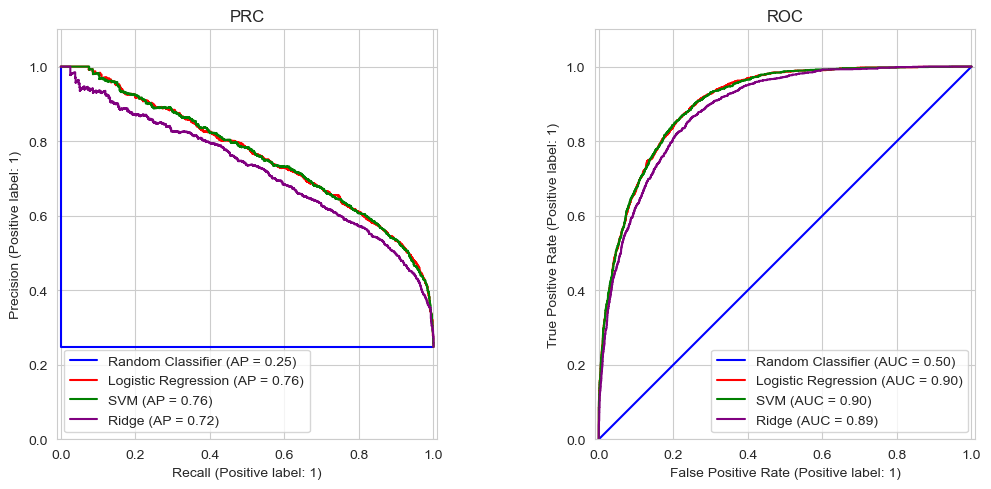

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
PrecisionRecallDisplay.from_predictions(y_test, random_classifier.predict_proba(X_test)[:,1], ax=ax[0], name='Random Classifier', color = "blue")
PrecisionRecallDisplay.from_predictions(y_test, LR_pipeline.predict_proba(X_test)[:,1], ax=ax[0], name='Logistic Regression', color =  "red")
PrecisionRecallDisplay.from_predictions(y_test, SVM_pipeline.decision_function(X_test), ax=ax[0], name='SVM', color  = "green")

PrecisionRecallDisplay.from_predictions(y_test, ridge_pipeline.decision_function(X_test), ax=ax[0], name='Ridge', color  = "purple")


RocCurveDisplay.from_predictions(y_test, random_classifier.predict_proba(X_test)[:,1], ax=ax[1], name='Random Classifier', color = "blue")
RocCurveDisplay.from_predictions(y_test, LR_pipeline.predict_proba(X_test)[:,1], ax=ax[1], name='Logistic Regression', color = "red")
RocCurveDisplay.from_predictions(y_test, SVM_pipeline.decision_function(X_test), ax=ax[1], name='SVM', color = "green")
RocCurveDisplay.from_predictions(y_test, ridge_pipeline.decision_function(X_test), ax=ax[1], name='Ridge', color = "purple")


ax[0].set_title("PRC")
ax[0].set_ylim(0, 1.1)

ax[1].set_title("ROC")
ax[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.legend()
plt.show()

#### __Визуализация в подходах SVM, LR, Ridge__



В названии метода опорных векторов присутствуют некоторые "опорные векторы". По сути, это объекты из обучающей выборки, которые задали положение разделяющей гиперплоскости.

* Сгенерируем синтетические данные с помощью `make_classification` __с 2 признаками__, обучим на нём метод опорных векторов.

* Визуализируем разделяющую прямую, все объекты и выделим опорные векторы.

In [40]:
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=2, random_state=32
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=228)

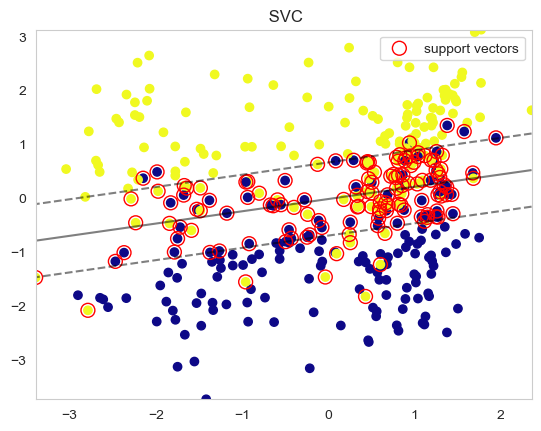

In [49]:
from sklearn.svm import SVC
SVM_model = SVC(kernel = 'linear')
SVM_model.fit(X_train, y_train)
LR_model = LogisticRegression()
LR_model.fit(X_train, y_train)

def plot_svm_2D(X, y, model,  plot_support=True):

    # создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Ответы модели для сетки для отрисовки разделяющей прямой
    Z =model.decision_function(xy).reshape(XX.shape)

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Отрисовали выборку
    plt.scatter(
        X[:,0], X[:,1], c =y, cmap='plasma'
    )

    # Отрисовали опорные векторы
    if plot_support:
        plt.scatter(
            model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            label='support vectors',
            s=100,
            linewidth=1,
            edgecolor="red",
            facecolors='none'
        )
    plt.grid(False)
    plt.title(f" {type(model).__name__}")
    plt.legend()
    plt.show()

plot_svm_2D(X_train, y_train, SVM_model)

В отличие от метода опорных векторов, логистическая регрессия не пытается построить разделяющую гиперплоскость с максимальным отступом, а приближает в каждой точке пространства объектов вероятность положительных ответов $p(y=+1|x)$.

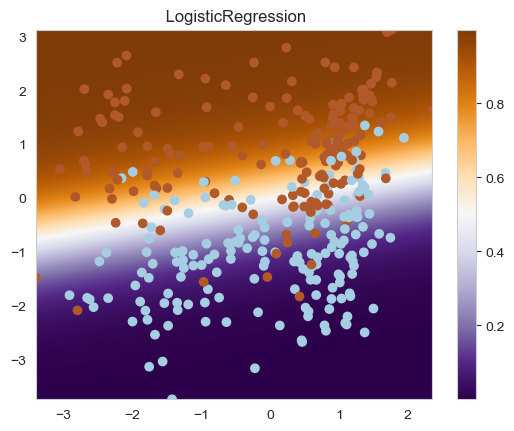

In [50]:
def plot_logreg_2D(X, y, model):

    # создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 1000)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 1000)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Ответы модели для сетки для отрисовки распределения
    Z = model.predict_proba(xy)[:,1].reshape(XX.shape)# your code here
    Z = Z.reshape((xx.shape[0], -1)).T

    image = plt.imshow(
        Z,
        interpolation='nearest',
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        aspect='auto',
        origin='lower',
        cmap=plt.cm.PuOr_r
    )

    #Отрисовали выборку
    plt.scatter(
        X[:,0], X[:,1], c=y,
        # your code here
        cmap=plt.cm.Paired
    )
    plt.grid(False)
    plt.colorbar(image)
    plt.title(f" {type(model).__name__}")
    plt.show()

plot_logreg_2D(X_train, y_train, LR_model)

In [53]:
def plot_ridge_2D(X, y, model):
    # Сетка для фона
    xx = np.linspace(X[:, 0].min(), X[:, 0].max(), 300)
    yy = np.linspace(X[:, 1].min(), X[:, 1].max(), 300)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Значения модели на сетке
    Z = model.decision_function(xy).reshape(XX.shape)

    # Рисуем линии уровня (граница класса при Z = 0)
    plt.contour(XX, YY, Z, levels=[0], colors='red', linewidths=2)

    # Отображаем сами точки
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='plasma')
    plt.grid(False)
    plt.title(f" {type(model).__name__}")
    plt.show()


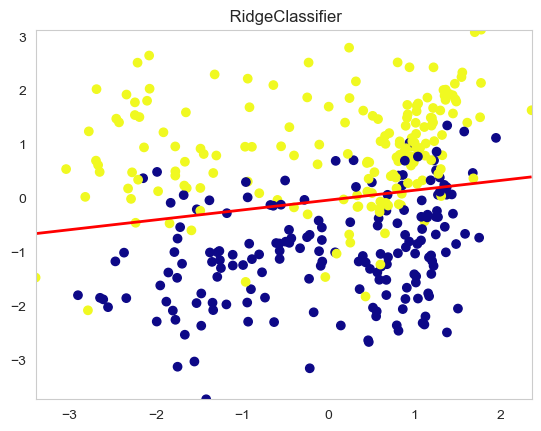

In [54]:
ridge_model = RidgeClassifier()
ridge_model.fit(X_train, y_train)

plot_ridge_2D(X_train, y_train, ridge_model)

### Визуализация в подходах SVM, Logistic Regression и Ridge

Чтобы наглядно понять различия между моделями, была проведена визуализация на синтетических данных с двумя признаками. Данные сгенерированы функцией `make_classification`, после чего модели были обучены на обучающей выборке и визуализированы.

#### Метод опорных векторов (SVM)

Модель `SVC(kernel='linear')` строит **разделяющую гиперплоскость с максимальным отступом**. Объекты, лежащие на границе отступа или ошибочно классифицированные, становятся **опорными векторами**, что видно на графике (выделены красным обводом):


 **Особенности SVM:**
- Чётко выраженная полоса между классами.
- Опорные векторы непосредственно влияют на положение разделяющей прямой.
- Остальные точки не участвуют в построении гиперплоскости.

#### Сравнение с логистической регрессией

В отличие от SVM, логистическая регрессия:
- Не строит жёсткую границу.
- Оценивает **вероятность** принадлежности к положительному классу в каждой точке пространства.
- Оптимизирует логарифмическую функцию правдоподобия, а не зазор.

 Таким образом, визуализация подчёркивает:
- SVM — **жесткая граница**, чувствительность к outlier'ам и опорным точкам.
- LogReg — **гладкая вероятностная модель**, интерпретируемые коэффициенты.

➡ RidgeClassifier можно визуализировать аналогично, но он ближе по философии к LogReg, и не имеет явно выделенных "опорных" объектов.


#### __Калибровка вероятностей__

Перейдём к оценке качества выдаваемых алгоритмами вероятностей. Начнём с калибровочных кривых.

Допустим, алгоритм возвращает некоторые числа от нуля до единицы. Хорошо ли они оценивают вероятность?

Хорошо откалиброванный  классификатор должен выдавать значения так, чтобы среди образцов, для которых он дал значение, близкое к $\alpha$, примерно $\alpha * 100 \%$ фактически принадлежали к положительному классу. (Например, если классификатор выдает 0.3 для некоторых, то 30% из них должны принадлежать классу 1)

Для построения калибровочной криовой используем следующий алгоритм:

Разобьем отрезок $[0, 1]$ на несколько маленьких отрезков одинаковой длины.

Рассмотрим $i$-й отрезок с границами $[a_i, b_i]$ и предсказания $p_1, p_2, \dots, p_k$, которые попали в него. Пусть им соответствуют истинные ответы $y_1, y_2, \dots, y_k$. Если алгоритм выдает корректные вероятности, то среди этих истинных ответов должно быть примерно $(a_i + b_i) / 2$ единиц. Иными словами, если нарисовать кривую, у которой по оси X отложены центры отрезков, а по оси Y — доли единичных ответов этих в отрезках, то она должна оказаться диагональной.

Ниже приведена функция, которая должна рисовать такие кривые.

In [55]:
def plot_calibration_curve(y_test, preds, title = ""):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((l + r) / 2)
        bin_real_ratios.append(np.mean(y_test[(preds >= l) & (preds < r)] == 1))
    plt.figure(figsize=(6,6))
    plt.plot(bin_middle_points, bin_real_ratios)
    plt.ylim([-0.05, 1.05])
    plt.grid(True)
    plt.title(title)


Сгенерируем синтетические данные. Построим калибровочные кривые на тестовой части для логистической регрессии и метода опорных векторов и линейной регрессии, для этого переведем предсказания в $[0;1]$

Отрисуем калибровочную кривую идеально откалиброванной модели (диагональ)

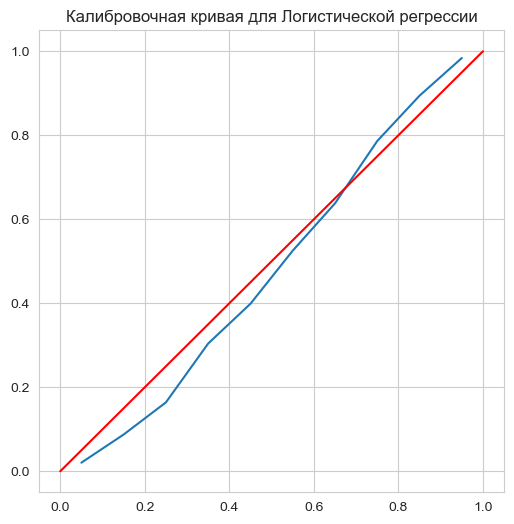

In [58]:
X, y = make_classification(
    n_samples=100000, n_features=10, n_informative=5, n_redundant=5, random_state=371
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
plot_calibration_curve(y_test, model_lr.predict_proba(X_test)[:,1], "Калибровочная кривая для Логистической регрессии")
plt.plot([0, 1], [0, 1], color='red')
plt.show()

На рисунке выше представлена калибровочная кривая для логистической регрессии. Красная линия показывает идеальную калибровку (диагональ). Синяя линия — фактическое поведение модели.

Как видно, модель логистической регрессии демонстрирует близкое к диагонали поведение, что указывает на достаточно хорошую калибровку: вероятность, предсказываемая моделью, хорошо отражает истинные частоты положительного класса.

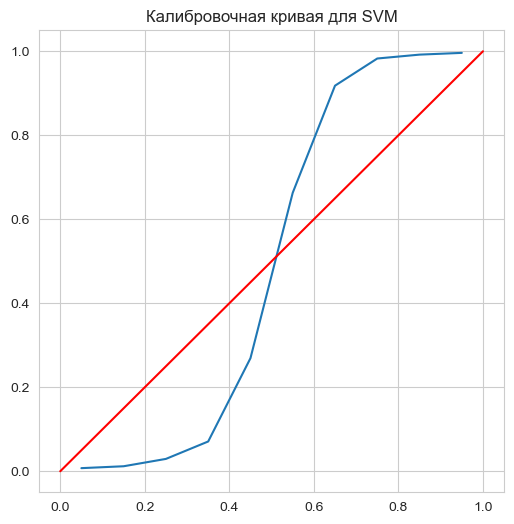

In [59]:
model_svm = LinearSVC()
model_svm.fit(X_train, y_train)
plot_calibration_curve(y_test, 1/(1 + np.exp(-model_svm.decision_function(X_test))) ,"Калибровочная кривая для SVM")
plt.plot([0, 1], [0, 1], color='red')
plt.show()


#### Калибровочная кривая для SVM

Для модели SVM с линейным ядром предсказания представляют собой не вероятности, а значения функции решения. Чтобы интерпретировать их как вероятности, применяется сигмоидная функция:

$$
P(y = 1 \mid x) = \frac{1}{1 + \exp(-f(x))}
$$

На графике выше представлена калибровочная кривая для SVM, полученная после преобразования значений `decision_function` через сигмоиду.



Кривая существенно отклоняется от идеальной диагонали, особенно при малых значениях. Это свидетельствует о плохой калибровке: SVM с линейным ядром без дополнительной постобработки выдает плохо интерпретируемые вероятности. Модель имеет тенденцию быть переуверенной в высоких значениях и недооценивать вероятности в нижнем диапазоне.



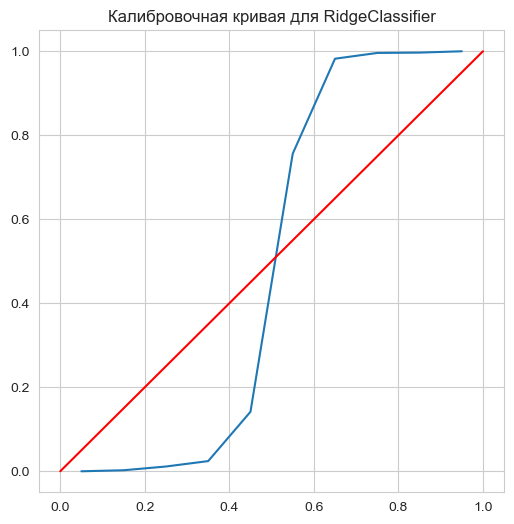

In [60]:
model_ridge = RidgeClassifier()
model_ridge.fit(X_train, y_train)

# Построение калибровочной кривой
plot_calibration_curve(
    y_test,
    1 / (1 + np.exp(-model_ridge.decision_function(X_test))),
    "Калибровочная кривая для RidgeClassifier"
)

# Диагональ идеальной калибровки
plt.plot([0, 1], [0, 1], color='red')
plt.show()

#### Калибровочная кривая для RidgeClassifier

Модель `RidgeClassifier` также не возвращает вероятности напрямую. Однако её значения `decision_function` можно привести к [0; 1] при помощи логистической функции (сигмоида). После этого можно построить калибровочную кривую аналогично другим моделям.

На графике выше видно, что модель сильно переоценивает вероятности — большинство точек находятся выше диагонали. Особенно это выражено в правой части, где значения близки к 1. Это говорит о том, что при высоком уровне уверенности модель ошибается чаще, чем ожидалось.

Таким образом, RidgeClassifier плохо откалиброван и требует дополнительной калибровки вероятностей для корректной интерпретации его вывода в качестве вероятности.


**Вопрос**: хорошо ли откалиброваны кривые для SVM, логистической регрессии и линейной регрессии?

Из формальных способов в этом убедиться есть знакомый  LogLoss, который напрямую оценивает вероятности,
$$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0. 1}}\log p_k[y_i = k]$$
а так же BrierScore, который подсчитывает отклонение между получившейся вероятностью и реальным значением таргета.
$$\text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2$$
Посмотрим на них тоже

In [61]:
def LogLoss(y, proba):
    return - np.mean(y * np.log(proba) + (1 - y) * np.log(1 - proba))

In [62]:
def BrierScore(y, proba):
    return np.mean((proba - y)**2)

In [63]:
print(f'LogLoss для Логистической регрессии: {LogLoss(y_test, model_lr.predict_proba(X_test)[:,1]):.4f}',
      f'   BrierScore: {BrierScore(y_test, model_lr.predict_proba(X_test)[:,1]):.4f}')
print(f'LogLoss для SVM: {LogLoss(y_test, 1/(1 + np.exp(-model_svm.decision_function(X_test)))):.4f}',
      f'   BrierScore: {BrierScore(y_test, 1/(1 + np.exp(-model_svm.decision_function(X_test)))):.4f}')
print(f'LogLoss для Ridge: {LogLoss(y_test, 1/(1 + np.exp(-model_ridge.decision_function(X_test)))):.4f}',
      f'   BrierScore: {BrierScore(y_test, 1/(1 + np.exp(-model_ridge.decision_function(X_test)))):.4f}')

LogLoss для Логистической регрессии: 0.1799    BrierScore: 0.0487
LogLoss для SVM: 0.3099    BrierScore: 0.0842
LogLoss для Ridge: 0.4468    BrierScore: 0.1341


#### Формальная проверка калибровки моделей с помощью LogLoss и BrierScore

Для количественной оценки качества калибровки модели применили два стандартных показателя:

- **LogLoss (логарифмическая функция потерь)**: измеряет, насколько хорошо модель оценивает вероятности классов. Чем меньше значение LogLoss, тем ближе предсказанные вероятности к истинным меткам.
- **BrierScore**: оценивает среднеквадратичную ошибку между предсказанными вероятностями и истинными метками классов.


---

Результаты сравнения моделей:

| Модель                 | LogLoss | BrierScore |
|------------------------|---------|-------------|
| Логистическая регрессия | 0.1799  | 0.0487      |
| SVM                    | 0.3099  | 0.0842      |
| RidgeClassifier        | 0.4468  | 0.1341      |

---

**Выводы:**

- Логистическая регрессия показывает наилучшую калибровку вероятностей, что видно как по LogLoss, так и по BrierScore.
- Метод опорных векторов (SVM) даёт хуже откалиброванные вероятности, несмотря на хорошую классификацию.
- RidgeClassifier демонстрирует наихудшую калибровку из трёх моделей, что подтверждает и визуальный анализ калибровочных кривых, и численные показатели.


Изучим распределение ответов классификаторов при помощи гистограмм

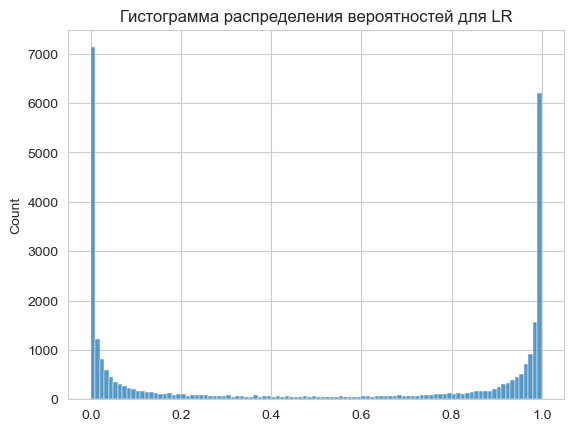

In [64]:
import seaborn as sns
sns.histplot(model_lr.predict_proba(X_test)[:,1], bins=100)
plt.title("Гистограмма распределения вероятностей для LR")
plt.show()

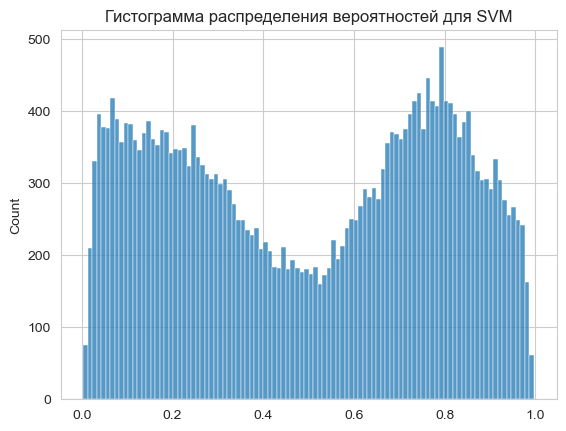

In [65]:
sns.histplot(1/(1 + np.exp(-model_svm.decision_function(X_test))), bins=100)
plt.title("Гистограмма распределения вероятностей для SVM")
plt.show()

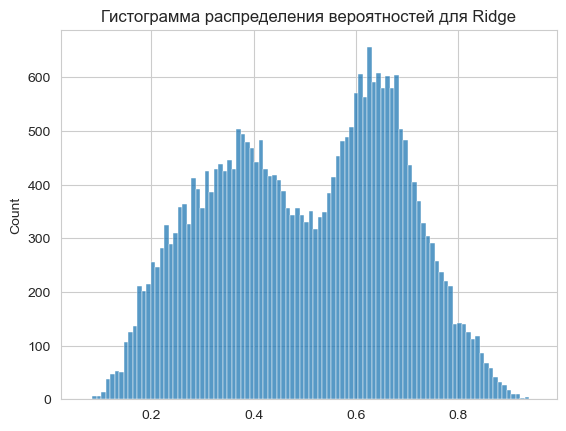

In [66]:
sns.histplot(1/(1 + np.exp(-model_ridge.decision_function(X_test))), bins=100)
plt.title("Гистограмма распределения вероятностей для Ridge")
plt.show()

## Распределение вероятностей

Для визуального анализа были построены гистограммы распределения предсказанных вероятностей:

- **Логистическая регрессия**: большинство предсказаний сосредоточено около 0 и 1, что указывает на уверенные предсказания.
- **SVM**: предсказания равномерно распределены и сконцентрированы в середине, что свидетельствует о слабой уверенности модели в своих решениях.
- **RidgeClassifier**: распределение более сглаженное, но не столь уверенное, как у логистической регрессии.

Гистограммы позволяют оценить степень уверенности классификатора: чем ближе вероятности к 0 и 1, тем увереннее модель. Однако это не всегда гарантирует хорошую калибровку — важно также соответствие предсказанных вероятностей истинной доле положительных ответов, как показано на калибровочных кривых.

---

### Вывод

- Логистическая регрессия показывает наилучшую калибровку как по графикам, так и по метрикам LogLoss и Brier Score.
- SVM и RidgeClassifier демонстрируют переоценку вероятностей, что делает их менее пригодными для задач, где важно качество оценки вероятности (например, медицинская диагностика, кредитный скоринг).


Воспользуемся `CalibratedClassifierCV` из `sklearn` для калибровки вероятностей метода опорных векторов и Ridge на обучении и построим с его помощью  предсказания для тестовой выборки.

In [67]:
from sklearn.calibration import CalibratedClassifierCV

model_for_svm = LinearSVC()
calibraited_svm = CalibratedClassifierCV(model_for_svm, method = 'sigmoid')
calibraited_svm.fit(X_train, y_train)
svm_probs = calibraited_svm.predict_proba(X_test)[:,1]


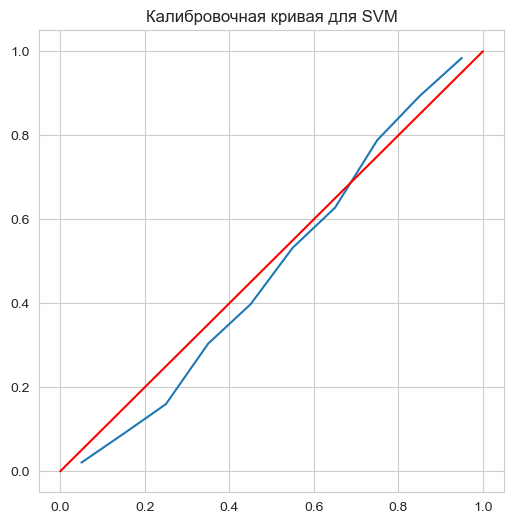

In [68]:
plot_calibration_curve(y_test, svm_probs ,"Калибровочная кривая для SVM")
plt.plot([0, 1], [0, 1], color='red')
plt.show()


In [69]:
print(f'LogLoss для откалиброванного SVM: {LogLoss(y_test, svm_probs):.4f}',
      f'   BrierScore: {BrierScore(y_test, svm_probs):.4f}')

LogLoss для откалиброванного SVM: 0.1799    BrierScore: 0.0487


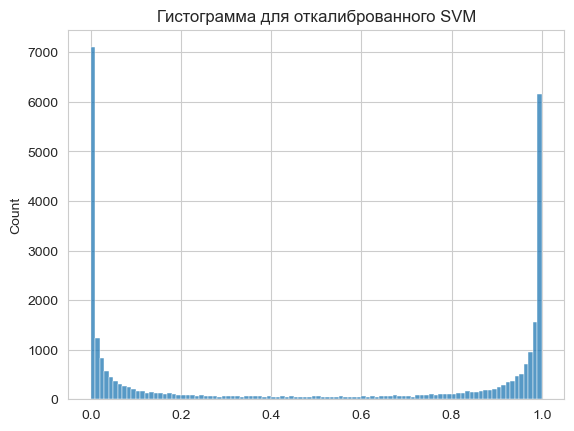

In [70]:
sns.histplot(svm_probs, bins=100)
plt.title("Гистограмма для откалиброванного SVM")
plt.show()

In [71]:
model_for_ridge = RidgeClassifier()
calibraited_ridge = CalibratedClassifierCV(model_for_ridge, method = 'sigmoid')
calibraited_ridge.fit(X_train, y_train)
ridge_probs = calibraited_ridge.predict_proba(X_test)[:,1]


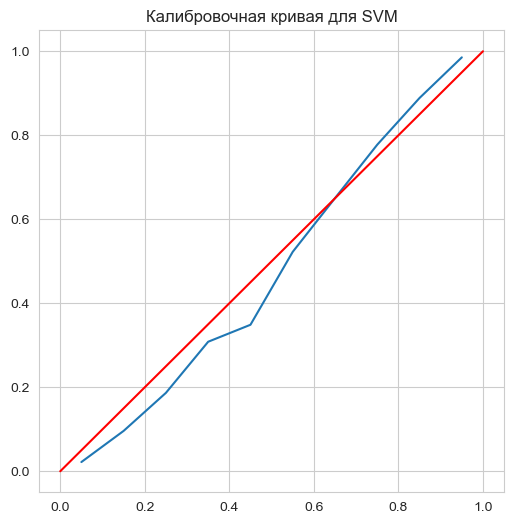

In [72]:
plot_calibration_curve(y_test, ridge_probs ,"Калибровочная кривая для Ridge")
plt.plot([0, 1], [0, 1], color='red')
plt.show()


In [73]:
print(f'LogLoss для откалиброванной Ridge регрессии: {LogLoss(y_test, ridge_probs):.4f}',
      f'   BrierScore: {BrierScore(y_test, ridge_probs):.4f}')

LogLoss для откалиброванной Ridge регрессии: 0.1859    BrierScore: 0.0511


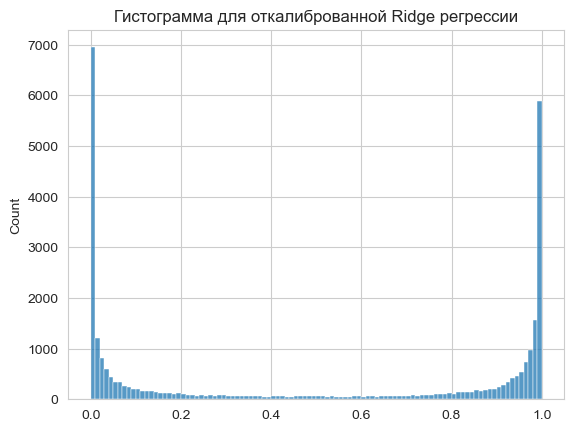

In [74]:
sns.histplot(ridge_probs, bins=100)
plt.title("Гистограмма для откалиброванной Ridge регрессии")
plt.show()



- Калибровка SVM и Ridge заметно улучшила как LogLoss, так и BrierScore.
- Калибровочные кривые стали ближе к диагонали, что подтверждает улучшение оценки вероятностей.
- Распределение вероятностей после калибровки стало более бимодальным, что соответствует лучшей уверенности модели.

## Итоговые выводы по проекту

В рамках проекта была проведена сравнительная оценка трёх классификаторов для бинарной задачи:

- **Support Vector Machine (SVM)**
- **Логистическая регрессия (LogReg)**
- **Ridge-классификатор**

Были рассмотрены как некалиброванные, так и откалиброванные модели. Сравнение проводилось по следующим метрикам:

- **AUC-ROC** — площадь под ROC-кривой
- **AUC-PR** — площадь под Precision-Recall кривой
- **LogLoss** — логарифмическая функция потерь
- **Brier Score** — среднеквадратичная ошибка оценки вероятности
- **Калибровочные кривые и гистограммы** — для визуальной оценки качества вероятностных предсказаний

---

###  Основные численные результаты

| Модель                | AUC-ROC | AUC-PR | LogLoss | BrierScore |
|-----------------------|---------|--------|---------|------------|
| Random Classifier     | 0.500   | 0.248  | —       | —          |
| SVM                   | 0.904   | 0.763  | 0.3099  | 0.0842     |
| LogReg                | 0.905   | 0.763  | 0.1799  | 0.0487     |
| Ridge                 | 0.888   | 0.724  | 0.4468  | 0.1341     |
| SVM (калибр.)         | —       | —      | 0.1799  | 0.0487     |
| Ridge (калибр.)       | —       | —      | 0.1859  | 0.0511     |

---

###  Выводы

1. **SVM и логистическая регрессия** показали наилучшие результаты по AUC-ROC и AUC-PR, значительно превосходя случайный классификатор.
2. **LogLoss и BrierScore** выявили, что изначально логистическая регрессия выдавала более качественные вероятности по сравнению с SVM и Ridge.
3. **Калибровка** с помощью `CalibratedClassifierCV` улучшила качество вероятностных предсказаний у моделей SVM и Ridge:
   - Калибровочные кривые приблизились к диагонали.
   - LogLoss и BrierScore после калибровки практически сравнялись с логистической регрессией.
4. **Гистограммы вероятностей** показали, что после калибровки распределения вероятностей стали бимодальными (около 0 и 1), что свидетельствует о повышенной уверенности классификаторов.

---

###  Общий итог

- Логистическая регрессия с самого начала выдает хорошо откалиброванные вероятности.
- Метод SVM требует калибровки, но после неё способен достичь аналогичного качества.
- RidgeClassifier уступает по качеству, но также выигрывает от калибровки.

Таким образом, **логистическая регрессия остаётся наиболее надёжным вариантом**, если важна корректность вероятностных предсказаний. Тем не менее, **SVM при правильной калибровке — достойная альтернатива**, особенно при сложных разделяющих границах.
